# Credit Card Fraud Detection — Exploratory Data Analysis

**Dataset:** Sparkov simulated transactions (`Credit Card Train Data.csv`, 1,296,675 rows).

## Business problem
Banks must flag fraudulent card transactions *before* they are approved. The challenge is **extreme class imbalance** — only ~0.58% of transactions are fraud. A model that predicts "never fraud" scores 99.4% accuracy while catching **zero** fraud, so **accuracy is the wrong metric**. We care about:

- **Recall** — of all real frauds, how many did we catch? (missed fraud = direct loss)
- **Precision** — of all flagged transactions, how many were real fraud? (false alarms = manual-review cost)
- **PR-AUC** — the right summary metric for rare-positive problems.

This notebook profiles the data and identifies which signals actually predict fraud.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ROOT / "Credit Card Train Data.csv", index_col=0)
print(f"{df.shape[0]:,} rows x {df.shape[1]} cols")
df.head(3)

1,296,675 rows x 22 cols


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


## 1. Data quality & schema

In [2]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df.dtypes

Missing values: 0


Duplicate rows: 0


trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

**Note on columns to drop later (leakage / PII):** `first`, `last`, `street`, `trans_num`, raw `cc_num`, and `unix_time` (a duplicate of the timestamp). Keeping per-customer identifiers would let the model memorise individuals rather than learn fraud behaviour.

## 2. Class imbalance — the core challenge

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
Fraud rate: 0.579%  (1 fraud per 172 legit)


C:\Users\triaz\AppData\Local\Temp\claude\ipykernel_39016\3257565181.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Legit (0)", "Fraud (1)"], y=vc.values, ax=ax, palette=["#4c72b0", "#c44e52"])


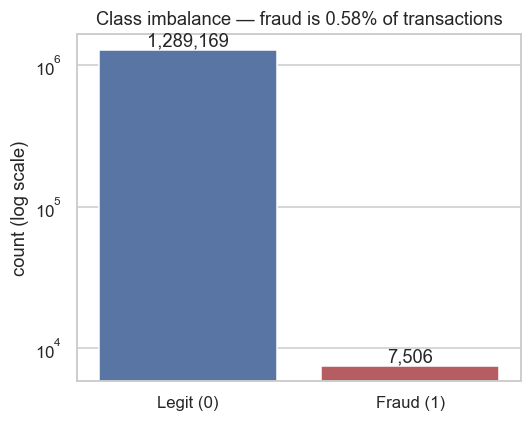

In [3]:
vc = df["is_fraud"].value_counts()
rate = df["is_fraud"].mean() * 100
print(vc)
print(f"Fraud rate: {rate:.3f}%  (1 fraud per {int(round(vc[0]/vc[1]))} legit)")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=["Legit (0)", "Fraud (1)"], y=vc.values, ax=ax, palette=["#4c72b0", "#c44e52"])
ax.set_yscale("log")
ax.set_ylabel("count (log scale)")
ax.set_title(f"Class imbalance — fraud is {rate:.2f}% of transactions")
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
fig.tight_layout(); fig.savefig(FIG / "01_class_imbalance.png"); plt.show()

## 3. Transaction amount — the strongest signal

                mean      50%      75%       max
is_fraud                                        
0          67.667110   47.280   82.540  28948.90
1         531.320092  396.505  900.875   1376.04


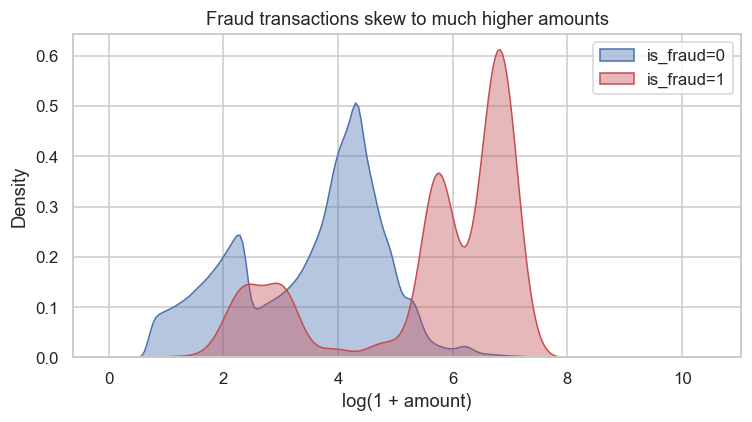

In [4]:
print(df.groupby("is_fraud")["amt"].describe()[["mean", "50%", "75%", "max"]])

fig, ax = plt.subplots(figsize=(7, 4))
for label, color in [(0, "#4c72b0"), (1, "#c44e52")]:
    sns.kdeplot(np.log1p(df.loc[df.is_fraud == label, "amt"]), label=f"is_fraud={label}",
                fill=True, alpha=0.4, color=color, ax=ax)
ax.set_xlabel("log(1 + amount)"); ax.set_title("Fraud transactions skew to much higher amounts")
ax.legend(); fig.tight_layout(); fig.savefig(FIG / "02_amount_by_class.png"); plt.show()

Fraud averages **~$531** vs **~$68** for legit transactions — amount alone is highly discriminative.

## 4. Time of day — fraud is a night-time phenomenon

C:\Users\triaz\AppData\Local\Temp\claude\ipykernel_39016\2018898465.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_hour.index, y=by_hour.values, ax=ax, palette=colors)


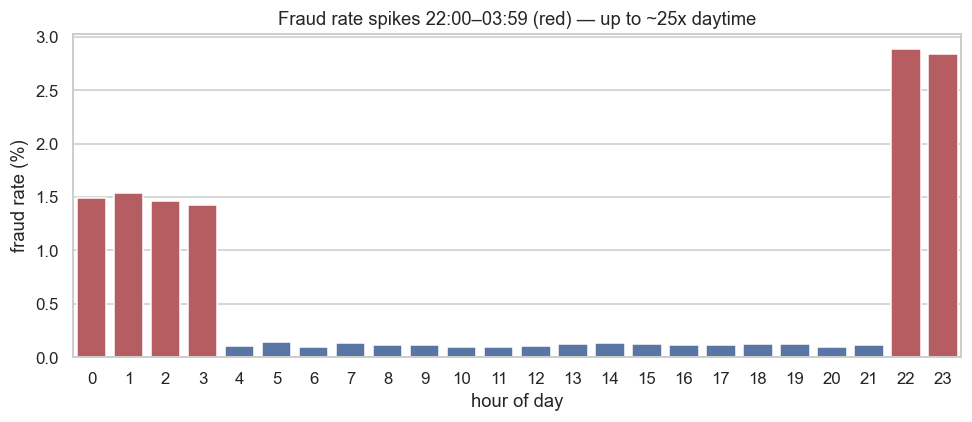

In [5]:
ts = pd.to_datetime(df["trans_date_trans_time"])
df["hour"] = ts.dt.hour
by_hour = df.groupby("hour")["is_fraud"].mean().mul(100)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#c44e52" if (h >= 22 or h <= 3) else "#4c72b0" for h in by_hour.index]
sns.barplot(x=by_hour.index, y=by_hour.values, ax=ax, palette=colors)
ax.set_xlabel("hour of day"); ax.set_ylabel("fraud rate (%)")
ax.set_title("Fraud rate spikes 22:00–03:59 (red) — up to ~25x daytime")
fig.tight_layout(); fig.savefig(FIG / "03_fraud_by_hour.png"); plt.show()

## 5. Category — online categories carry more risk

C:\Users\triaz\AppData\Local\Temp\claude\ipykernel_39016\2849760555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=by_cat.index, x=by_cat.values, ax=ax, palette="rocket_r")


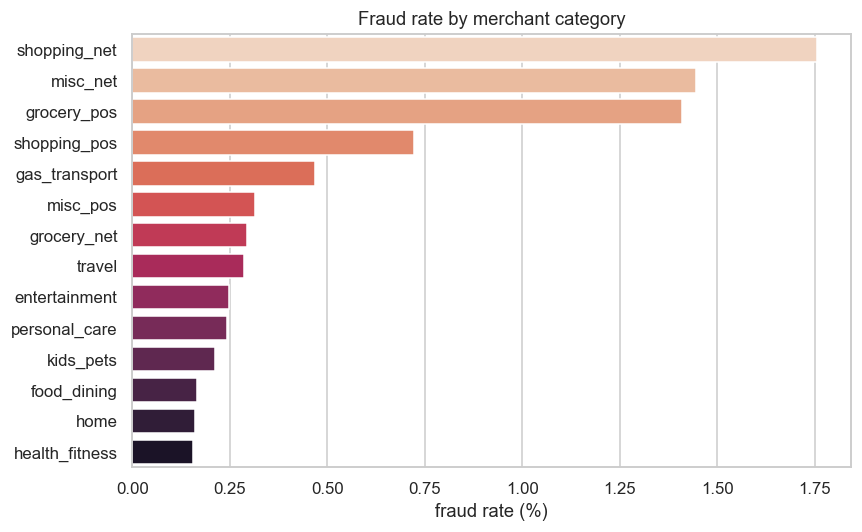

category
shopping_net      1.756
misc_net          1.446
grocery_pos       1.410
shopping_pos      0.723
gas_transport     0.469
misc_pos          0.314
grocery_net       0.295
travel            0.286
entertainment     0.248
personal_care     0.242
kids_pets         0.211
food_dining       0.165
home              0.161
health_fitness    0.155
Name: is_fraud, dtype: float64

In [6]:
by_cat = df.groupby("category")["is_fraud"].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(y=by_cat.index, x=by_cat.values, ax=ax, palette="rocket_r")
ax.set_xlabel("fraud rate (%)"); ax.set_ylabel("")
ax.set_title("Fraud rate by merchant category")
fig.tight_layout(); fig.savefig(FIG / "04_fraud_by_category.png"); plt.show()
by_cat.round(3)

## 6. A signal that does NOT work here: geo-distance

A common fraud heuristic is "transaction far from the cardholder's home." We test it with the haversine distance between cardholder (`lat`,`long`) and merchant (`merch_lat`,`merch_long`).

In [7]:
R = 6371.0
lat1, lon1, lat2, lon2 = map(np.radians, [df.lat, df.long, df.merch_lat, df.merch_long])
a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
df["dist_km"] = R * 2 * np.arcsin(np.sqrt(a))
print(df.groupby("is_fraud")["dist_km"].describe()[["mean", "50%", "max"]])
print("\nBoth classes average ~76 km -> distance is NOT predictive in this simulated data.")

               mean        50%         max
is_fraud                                  
0         76.113756  78.233012  152.117173
1         76.268330  77.931954  144.522410

Both classes average ~76 km -> distance is NOT predictive in this simulated data.


**Finding:** Both fraud and legit transactions average ~76 km from home. The simulator places merchants in the same radius regardless of fraud, so we will **not** engineer a distance feature for this dataset. (Verifying assumptions on real numbers beats inheriting heuristics.)

## Key takeaways → feature plan

| Signal | Verdict | Feature(s) to build |
|---|---|---|
| **amt** | 🔥 strongest | scaled amount, log-amount |
| **hour of day** | 🔥 strong | `hour`, `is_night` (22:00–03:59) |
| **category** | ✅ solid | target/one-hot encoding |
| **age** (from `dob`) | to test | `age` at transaction |
| **per-card behaviour** | to build | amount vs card's mean, txn velocity (leak-safe) |
| geo-distance | ❌ not predictive | *dropped* |

**Next:** `02_features_and_baseline` — engineer these features, drop PII/leakage columns, train a Logistic Regression baseline with `class_weight='balanced'`, and evaluate on the held-out test file with PR-AUC / recall / precision.